# Evaluating the Final Model on 2025-03-01 to 2026-02-28

We had initially held out 2025-03-01 to 2026-02-28. We shall use TimeSeriesSplit to see how our chosen model performs. Here, we are choosing Prophet since it performed the best.

## Import Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime

from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.linear_model import LinearRegression

from prophet import Prophet
from pandas.tseries.holiday import USFederalHolidayCalendar
from prophet.diagnostics import cross_validation, performance_metrics
from prophet.plot import plot_cross_validation_metric
from prophet.plot import add_changepoints_to_plot
from prophet.plot import plot_plotly, plot_components_plotly
import itertools

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter('ignore', ConvergenceWarning)

import optuna
from neuralprophet import NeuralProphet
import logging


Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.


## Load and Prepare Data

In [2]:
np.NaN = np.nan


# the following packages are meant to turn off a bunch of the warnings and ERRORs that pop up while running NeuralProphet.
# the errors that do show up are not all that important and a lot is due to outdated packages.
import warnings
import logging

warnings.filterwarnings("ignore")

logging.getLogger("neuralprophet").setLevel(logging.ERROR)
logging.getLogger("pytorch_lightning").setLevel(logging.ERROR)
logging.getLogger("NP").setLevel(logging.ERROR)

In [3]:
# Load the existing study
study = optuna.load_study(
    study_name="model_neural",
    storage="sqlite:///model_neural.db"
)

# Get the best parameters
best_params = study.best_params
best_value = study.best_value  # Optional: best objective value

print("Best parameters:", best_params)
print("Best objective value:", best_value)

Best parameters: {'lag_temp_max': 40, 'lag_temp_min': 12, 'lag_snowfall': 2, 'n_lags': 28, 'epochs': 249, 'learning_rate': 0.37721078987363893, 'batch_size': 1320, 'ar_reg': 2.538762924452284}
Best objective value: 5.2251618137843145


In [4]:
rs = pd.read_csv('../../scr/data/cleaned_rat_sightings_data/all_daily_borough_rs.csv')
rs['created_date'] = pd.to_datetime(rs['created_date']) 

# Start by cutting off data before 2020-01-01 and after 2026-02-28.
rs = rs[rs['created_date']<'2026-03-01']
rs = rs[rs['created_date']>='2020-01-01']

## Restrict to BROOKLYN

rs = rs[rs['borough']=='BROOKLYN']

## Drop the column with borough

rs = rs.drop(columns=['borough'])

## rename columns for prophet

rs.rename(columns={'created_date': 'ds', 'count': 'y'}, inplace=True)


## Add weather data.
import requests


lat, lon = 40.7831, -73.9712
start = "2020-01-01"
end   = "2026-02-28"

url = (
    "https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={lat}&longitude={lon}"
    f"&start_date={start}&end_date={end}"
    "&daily=temperature_2m_max,temperature_2m_min,temperature_2m_mean,"
    "apparent_temperature_max,apparent_temperature_min,apparent_temperature_mean,"
    "precipitation_sum,snowfall_sum"
    "&timezone=America/New_York"
)

response = requests.get(url)
data = response.json()


if 'error' in data:
    nd = pd.read_csv("../../scr/data/weather_data/wd_2020_to_march_2026.csv")
    nd = nd.set_index('time')
    wd = nd
    wd["date"] = pd.to_datetime(wd["time"])
    
else:
    wd = pd.DataFrame(data["daily"])
    wd["date"] = pd.to_datetime(wd["time"])
    wd = wd.set_index("date")

In [5]:
tscv = TimeSeriesSplit(gap=0, max_train_size=None, n_splits=26, test_size=14)

regressed_features = ['apparent_temperature_max', 'apparent_temperature_min','snowfall_sum']


wd = wd.reset_index(drop=True).rename(columns={"time": "ds"})
wd["ds"] = pd.to_datetime(wd["ds"])
rs["ds"] = pd.to_datetime(rs["ds"])

rs = rs.merge(
    wd[['ds'] + regressed_features],
    on="ds",
    how="left"
)

lags_for_regressed_features = dict()
lags_for_regressed_features['apparent_temperature_max'] = best_params['lag_temp_max']
lags_for_regressed_features['apparent_temperature_min'] = best_params['lag_temp_min']
lags_for_regressed_features['snowfall_sum'] = best_params['lag_snowfall']


results = []

for i, (train_index, test_index) in enumerate(tscv.split(rs)):

    train = rs.iloc[train_index].copy()
    train = train.dropna(subset=["y"])

    test = rs.iloc[test_index].copy()


    model = NeuralProphet(yearly_seasonality=True, 
                          weekly_seasonality=True, 
                          learning_rate = best_params['learning_rate'],
                          epochs = best_params['epochs'],
                          n_lags= best_params['n_lags'],
                          ar_reg=best_params['ar_reg'],
                          accelerator="auto",   # uses GPU if available
                          batch_size= best_params['batch_size']
                          )
    model = model.add_country_holidays(country_name="US")
    for column in regressed_features:
        model.add_lagged_regressor(column, n_lags=lags_for_regressed_features[column])
        
    model.fit(train, freq="D", progress="off")

    # build dataframe containing future regressors
    future = pd.concat([train[['ds','y'] + regressed_features], test[['ds','y']].merge(wd[['ds'] + regressed_features], on="ds", how="left")])
    forecast = model.predict(future)

    y_pred = forecast["yhat1"].iloc[-len(test):].values
    y_pred = np.round(y_pred)
    y_true = test["y"].values

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = mean_absolute_percentage_error(y_true, y_pred)

    results.append({"fold": i, "rmse": rmse, "mape": mape})

neural_prophet_results_df = pd.DataFrame(results)
neural_prophet_results_df.loc["mean"] = ["mean", neural_prophet_results_df["rmse"].mean(), neural_prophet_results_df["mape"].mean()]

Training: 0it [00:00, ?it/s]

Predicting: 2it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 2it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

...

Predicting: 2it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 2it [00:00, ?it/s]

Training: 0it [00:00, ?it/s]

Predicting: 2it [00:00, ?it/s]

## Results

In [6]:
neural_prophet_results_df

,fold,rmse,mape
0,0,8.215838,0.349171
1,1,4.200340,0.157750
2,2,5.688334,0.221000
3,3,5.203021,0.111813
4,4,7.020378,0.271688
5,5,5.700877,0.181622
6,6,7.191265,0.216481
7,7,7.111359,0.333428
8,8,6.475227,0.232320
9,9,6.964194,0.202131


## Plot

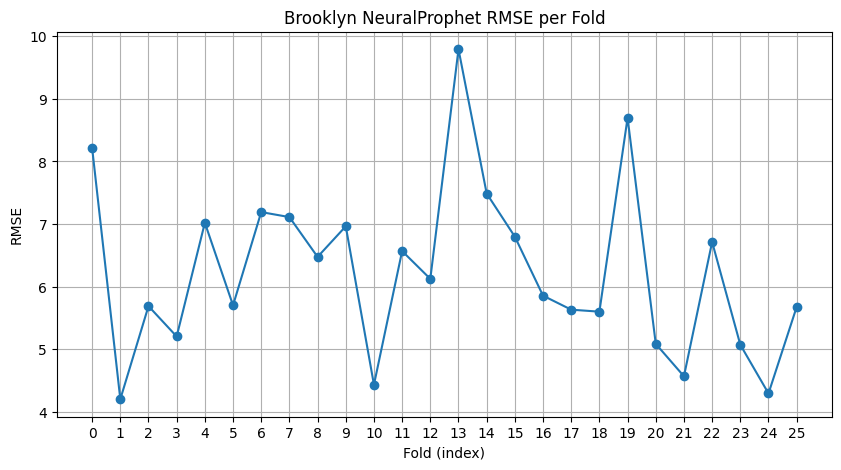

In [8]:
import matplotlib.pyplot as plt

# Reset index to turn the current index into a column
df_plot = neural_prophet_results_df.reset_index()

# Drop the row where the original index was 'mean'
df_plot = df_plot[df_plot['index'] != 'mean']

# Plot RMSE using the numeric index as x-axis
plt.figure(figsize=(10, 5))
plt.plot(df_plot.index, df_plot['rmse'], marker='o', linestyle='-')

plt.title("Brooklyn NeuralProphet RMSE per Fold")
plt.xlabel("Fold (index)")
plt.ylabel("RMSE")

plt.xticks(df_plot.index)  # show all fold numbers
plt.grid(True)

plt.show()